# Futures Alpha MOEX FORTS

Alpha research on four MOEX futures instruments: Si (USD/RUB), BR (Brent crude), MX (IMOEX mini), RI (RTS index). Three hypotheses tested: (1) overnight gap fade  does the gap between the evening session close and morning open revert intraday; (2) MX vs RI pairs trading  cointegrated pair linked by the USD/RUB exchange rate; (3) Si calendar spread  profiting from CBR rate cut expectations. Data: hourly candles from MOEX ISS (free, no authorization required).


In [1]:
import warnings, time, requests
import numpy as np
import pandas as pd
from scipy import stats
from statsmodels.tsa.stattools import adfuller
import matplotlib.pyplot as plt
import matplotlib.ticker as mtick
warnings.filterwarnings('ignore')
plt.rcParams.update({'figure.dpi': 120, 'axes.grid': True, 'grid.alpha': 0.3, 'font.size': 10})

# Константы 
COST_RT   = 0.04 / 100   # фьючерсы Tinkoff: 0.04% за сделку, одна нога, одна сторона
COST_2RT  = COST_RT * 2  # вход + выход, одна нога
START     = '2023-01-01'
END       = pd.Timestamp.today().strftime('%Y-%m-%d')

# H=Mar, M=Jun, U=Sep, Z=Dec; последняя цифра = год

# Si/MX/RI истекают в 3-й четверг месяца
EXPIRIES = {
    'H3': '2023-03-16', 'M3': '2023-06-15', 'U3': '2023-09-21', 'Z3': '2023-12-21',
    'H4': '2024-03-21', 'M4': '2024-06-20', 'U4': '2024-09-19', 'Z4': '2024-12-19',
    'H5': '2025-03-20', 'M5': '2025-06-19', 'U5': '2025-09-18', 'Z5': '2025-12-18',
    'H6': '2026-03-19', 'M6': '2026-06-18', 'U6': '2026-09-17', 'Z6': '2026-12-17',
}

# BR (Brent) истекает ~1-го числа месяца поставки (последний рабочий день предыдущего)
BR_EXPIRIES = {
    'H3': '2023-03-01', 'M3': '2023-06-01', 'U3': '2023-09-01', 'Z3': '2023-12-01',
    'H4': '2024-03-01', 'M4': '2024-06-03', 'U4': '2024-09-02', 'Z4': '2024-12-02',
    'H5': '2025-03-03', 'M5': '2025-06-02', 'U5': '2025-09-01', 'Z5': '2025-12-01',
    'H6': '2026-03-02', 'M6': '2026-06-02', 'U6': '2026-09-01', 'Z6': '2026-12-01',
}

def contracts_for(prefix):
    """Вернуть список (ticker, expiry_date) отсортированный по дате."""
    expiries = BR_EXPIRIES if prefix == 'BR' else EXPIRIES
    result = []
    for suffix, expiry_str in expiries.items():
        expiry = pd.Timestamp(expiry_str)
        if expiry >= pd.Timestamp(START) and expiry <= pd.Timestamp(END) + pd.Timedelta(days=100):
            result.append((f'{prefix}{suffix}', expiry))
    return sorted(result, key=lambda x: x[1])

# Проверяем
for prefix in ['Si', 'BR', 'MX', 'RI']:
    ctrs = contracts_for(prefix)
    print(f'{prefix}: {[t for t, _ in ctrs]}')

Si: ['SiH3', 'SiM3', 'SiU3', 'SiZ3', 'SiH4', 'SiM4', 'SiU4', 'SiZ4', 'SiH5', 'SiM5', 'SiU5', 'SiZ5', 'SiH6', 'SiM6', 'SiU6']
BR: ['BRH3', 'BRM3', 'BRU3', 'BRZ3', 'BRH4', 'BRM4', 'BRU4', 'BRZ4', 'BRH5', 'BRM5', 'BRU5', 'BRZ5', 'BRH6', 'BRM6', 'BRU6']
MX: ['MXH3', 'MXM3', 'MXU3', 'MXZ3', 'MXH4', 'MXM4', 'MXU4', 'MXZ4', 'MXH5', 'MXM5', 'MXU5', 'MXZ5', 'MXH6', 'MXM6', 'MXU6']
RI: ['RIH3', 'RIM3', 'RIU3', 'RIZ3', 'RIH4', 'RIM4', 'RIU4', 'RIZ4', 'RIH5', 'RIM5', 'RIU5', 'RIZ5', 'RIH6', 'RIM6', 'RIU6']


## 1. Data Loading  MOEX ISS

Endpoint: `/iss/engines/futures/markets/forts/securities/{TICKER}/candles.json`. Continuous series: for each contract, use data from its front-month period only. Cache in `data/cache/futures_hourly/`.


In [2]:
import pathlib, json

CACHE_DIR = pathlib.Path('data/cache/futures_hourly')
CACHE_DIR.mkdir(parents=True, exist_ok=True)

def fetch_futures_candles(ticker, interval=60, start=START, end=END):
    """
    Скачать часовые свечи фьючерса с MOEX ISS.
    interval: 60 = час, 24 = день
    """
    cache_path = CACHE_DIR / f'{ticker}_{interval}m.parquet'
    if cache_path.exists():
        return pd.read_parquet(cache_path)

    url = (f'https://iss.moex.com/iss/engines/futures/markets/forts/'
           f'securities/{ticker}/candles.json')
    all_rows = []
    offset = 0

    while True:
        params = {
            'interval': interval,
            'from': start,
            'till': end,
            'start': offset,
            'lang': 'ru',
        }
        try:
            r = requests.get(url, params=params, timeout=30)
            data = r.json()['candles']
        except Exception as e:
            print(f'    {ticker}: ошибка -- {e}')
            break

        # MOEX ISS возвращает columns как плоский список строк ['open','close',...,'begin','end']
        cols = list(data['columns'])
        rows = data['data']
        if not rows:
            break

        all_rows.extend(rows)
        if len(rows) < 500:
            break
        offset += len(rows)
        time.sleep(0.15)

    if not all_rows:
        return pd.DataFrame()

    df = pd.DataFrame(all_rows, columns=cols)
    df['begin'] = pd.to_datetime(df['begin'])
    df = df.rename(columns={'begin': 'dt', 'open': 'open', 'high': 'high',
                             'low': 'low', 'close': 'close', 'volume': 'vol'})
    df = df[['dt', 'open', 'high', 'low', 'close', 'vol']].sort_values('dt').reset_index(drop=True)
    df.to_parquet(cache_path)
    return df


def build_continuous(prefix, interval=60):
    """
    Собрать непрерывный ряд часовых свечей: каждый контракт берём
    в период, когда он является front-month (от экспирации предыдущего + 1д).
    """
    contracts = contracts_for(prefix)
    pieces = []

    for i, (ticker, expiry) in enumerate(contracts):
        roll_start = (contracts[i-1][1] + pd.Timedelta(days=1)).strftime('%Y-%m-%d') if i > 0 else START
        roll_end   = expiry.strftime('%Y-%m-%d')

        df = fetch_futures_candles(ticker, interval=interval, start=roll_start, end=roll_end)
        if df.empty:
            print(f'  {ticker}: нет данных')
            continue
        df['contract'] = ticker
        pieces.append(df)
        print(f'  {ticker}: {len(df):>5} баров ({df.dt.min().date()} → {df.dt.max().date()})')

    if not pieces:
        return pd.DataFrame()
    result = pd.concat(pieces).sort_values('dt').reset_index(drop=True)
    print(f'  → Итого {prefix}: {len(result)} баров ({result.dt.min().date()} → {result.dt.max().date()})')
    return result

df_si = build_continuous('Si')
df_br = build_continuous('BR')
df_mx = build_continuous('MX')
df_ri = build_continuous('RI')

Загружаем Si...
  SiH3:   755 баров (2023-01-03 → 2023-03-16)
  SiM3:   920 баров (2023-03-17 → 2023-06-15)
  SiU3:  1083 баров (2023-06-16 → 2023-09-21)
  SiZ3:  1004 баров (2023-09-22 → 2023-12-21)
  SiH4:   966 баров (2023-12-22 → 2024-03-21)
  SiM4:   992 баров (2024-03-22 → 2024-06-20)
  SiU4:   965 баров (2024-06-21 → 2024-09-19)
  SiZ4:   969 баров (2024-09-20 → 2024-12-19)
  SiH5:   964 баров (2024-12-20 → 2025-03-20)
  SiM5:   986 баров (2025-03-21 → 2025-06-19)
  SiU5:  1033 баров (2025-06-20 → 2025-09-18)
  SiZ5:  1033 баров (2025-09-19 → 2025-12-18)
  SiH6:   955 баров (2025-12-19 → 2026-03-19)
  SiM6:   977 баров (2026-03-20 → 2026-06-17)
  SiU6:  1697 баров (2026-01-05 → 2026-06-17)
  → Итого Si: 15299 баров (2023-01-03 → 2026-06-17)

Загружаем BR...
  BRH3:   610 баров (2023-01-03 → 2023-03-01)
  BRM3:   935 баров (2023-03-02 → 2023-06-01)
  BRU3:  1009 баров (2023-06-02 → 2023-09-01)
  BRZ3:   993 баров (2023-09-04 → 2023-12-01)
  BRH4:   971 баров (2023-12-04 → 2024-03

Инструмент           Баров                    Период  Avg vol/bar
────────────────────────────────────────────────────────────────────
  Si (USD/RUB)    :  15299    2023-01-03 → 2026-06-17        51174
  BR (Brent)      :  14123    2023-01-03 → 2026-06-17         8250
  MX (IMOEX mini) :  14268    2023-01-03 → 2026-06-17         6257
  RI (RTS)        :  14340    2023-01-03 → 2026-06-17         5251


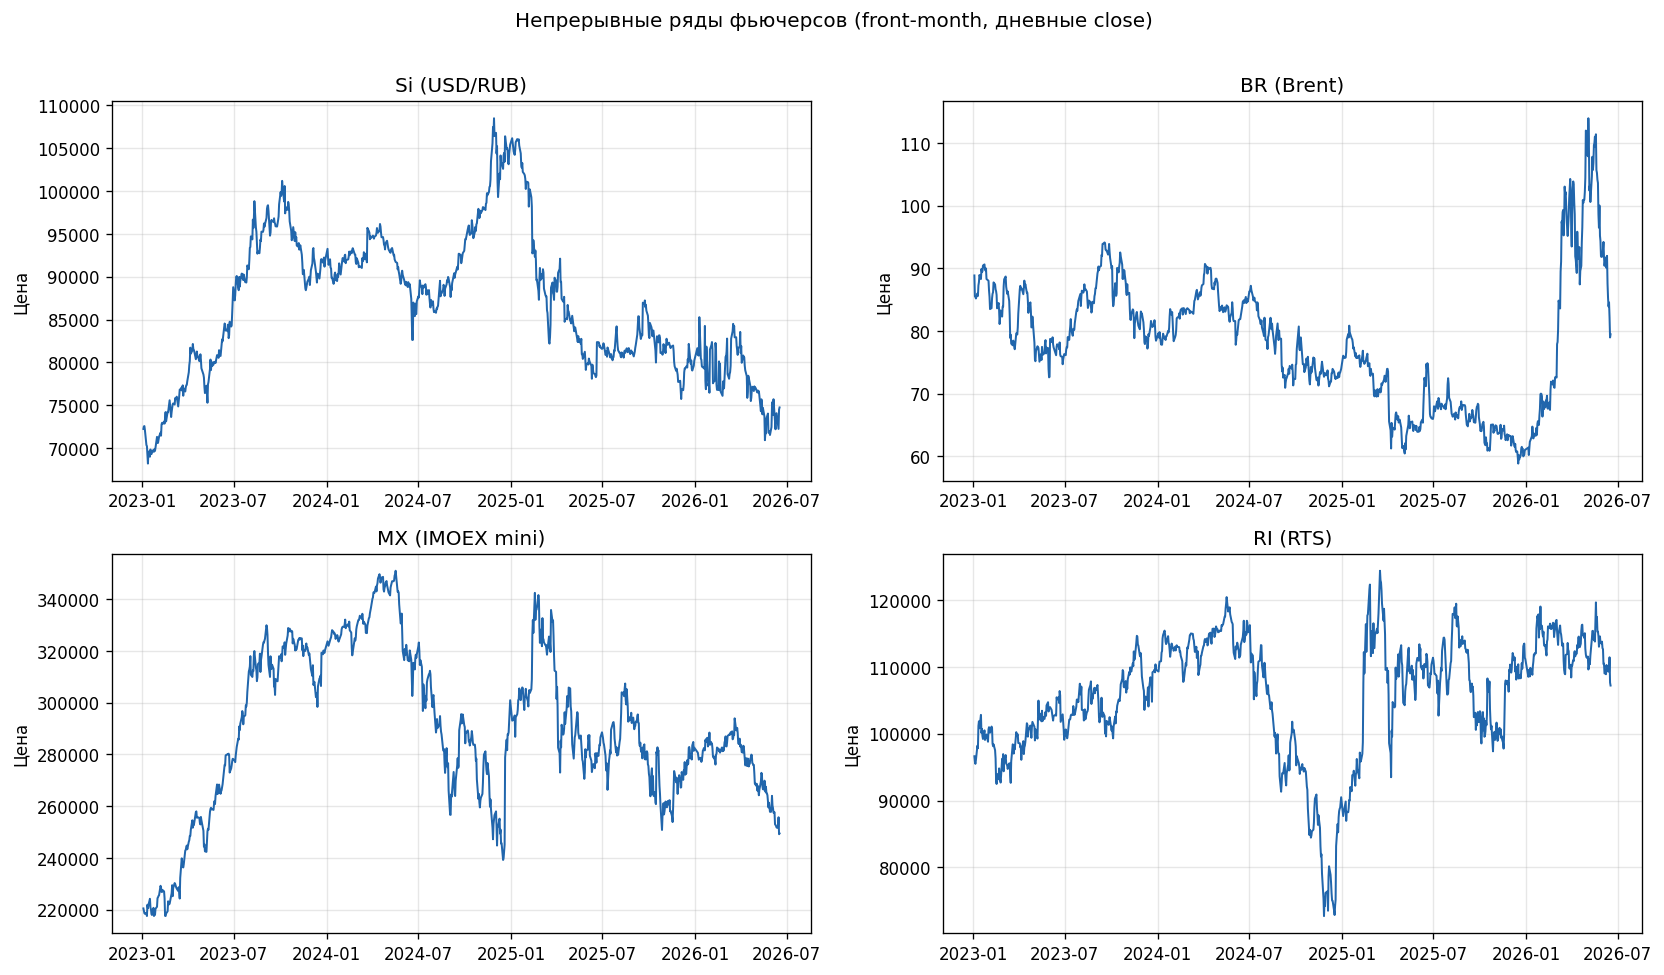

In [3]:
# Быстрая проверка данных 
instruments = {'Si (USD/RUB)': df_si, 'BR (Brent)': df_br,
               'MX (IMOEX mini)': df_mx, 'RI (RTS)': df_ri}

print(f"{'Инструмент':<18} {'Баров':>7} {'Период':>25} {'Avg vol/bar':>12}")
print('─' * 68)
for name, df in instruments.items():
    if df.empty:
        print(f'  {name:<16}: НЕТ ДАННЫХ')
        continue
    period = f"{df.dt.min().date()} → {df.dt.max().date()}"
    print(f"  {name:<16}: {len(df):>6}  {period:>25}  {df.vol.mean():>11.0f}")

# Нормализованные equity curves для визуализации
fig, axes = plt.subplots(2, 2, figsize=(14, 8), sharex=False)
for ax, (name, df) in zip(axes.flat, instruments.items()):
    if df.empty:
        ax.set_title(f'{name}: нет данных')
        continue
    daily = df.groupby(df.dt.dt.date)['close'].last().reset_index()
    daily['dt'] = pd.to_datetime(daily['dt'])
    ax.plot(daily['dt'], daily['close'], lw=1.2, color='#2166ac')
    ax.set_title(name)
    ax.set_ylabel('Цена')
plt.suptitle('Непрерывные ряды фьючерсов (front-month, дневные close)', fontsize=12, y=1.01)
plt.tight_layout()
plt.show()

## 2. Overnight Gap Analysis

FORTS session structure:
- Morning session: 10:00--18:45 MSK (main)
- Evening session: 19:00--23:50 MSK (low liquidity)
- Break: 00:00--09:59 MSK

Gap = `morning_open(10:00) / evening_close(23:xx) - 1`

Fade hypothesis: gaps form during the low-liquidity evening session and revert as the morning session opens with full order flow.


In [4]:
def compute_gaps(df_hourly, instr_name=''):
    """
    Overnight gaps: вечернее закрытие дня D → утреннее открытие дня D+1.

    Проблема с merge_asof: на FORTS вечерняя (19:00-23:50) и утренняя (09:00-18:45)
    сессии лежат на ОДНОМ календарном дне. Поэтому нельзя матчить по датам через
    merge_asof -- он всегда найдёт вечер того же дня.
    Решение: выравниваем по индексу дат и делаем .shift(1), чтобы вечер D-1
    попал в строку утра D.
    """
    df = df_hourly.copy()
    df['hour']    = df['dt'].dt.hour
    date_col      = df['dt'].dt.date

    # Вечерний close: последняя свеча вечерней сессии (≥19:00 МСК)
    ev_close = (df[df['hour'] >= 19]
                .groupby(date_col)['close'].last()
                .rename('ev_close'))

    # Утреннее открытие: первая свеча торгового дня
    mo_open  = (df.groupby(date_col)['open'].first()
                .rename('mo_open'))

    # Внутридневные high/low/close для симуляции stop/target
    day_high  = df.groupby(date_col)['high'].max().rename('day_high')
    day_low   = df.groupby(date_col)['low'].min().rename('day_low')
    day_close = df.groupby(date_col)['close'].last().rename('day_close')

    # Объединяем по датам в один датафрейм
    combined = pd.concat([ev_close, mo_open, day_high, day_low, day_close], axis=1)
    combined.index = pd.to_datetime(combined.index)
    combined.index.name = 'date'
    combined = combined.sort_index()

    # Сдвигаем ev_close на 1 позицию вперёд по торговым дням:
    # теперь каждая строка D содержит ev_close дня D-1 (предыдущего торгового дня)
    combined['ev_close'] = combined['ev_close'].shift(1)
    combined['gap']      = combined['mo_open'] / combined['ev_close'] - 1

    result = (combined
              .dropna(subset=['gap', 'mo_open', 'ev_close', 'day_high', 'day_low', 'day_close'])
              .reset_index())

    if instr_name:
        n = len(result)
        print(f'  {instr_name}: {n} overnight gaps '
              f'({result.date.min().date()} → {result.date.max().date()})')
    return result


gaps = {}
print('Вычисляем overnight gaps:')
for name, df in instruments.items():
    if not df.empty:
        gaps[name] = compute_gaps(df, name)

Вычисляем overnight gaps:
  Si (USD/RUB): 863 overnight gaps (2023-01-04 → 2026-06-17)
  BR (Brent): 862 overnight gaps (2023-01-04 → 2026-06-17)
  MX (IMOEX mini): 864 overnight gaps (2023-01-04 → 2026-06-17)
  RI (RTS): 864 overnight gaps (2023-01-04 → 2026-06-17)



Инструмент           Ср.гэп     std  % |gap|>0.2%  % |gap|>0.4%  % |gap|>0.7%
────────────────────────────────────────────────────────────────────────────────
  Si (USD/RUB)    :  -0.118%   0.797%          11.2%           7.6%           6.7%
  BR (Brent)      :   0.036%   0.842%          46.2%          23.0%          11.4%
  MX (IMOEX mini) :   0.027%   0.298%          18.6%           7.6%           3.5%
  RI (RTS)        :   0.015%   0.301%          19.7%           7.8%           3.5%


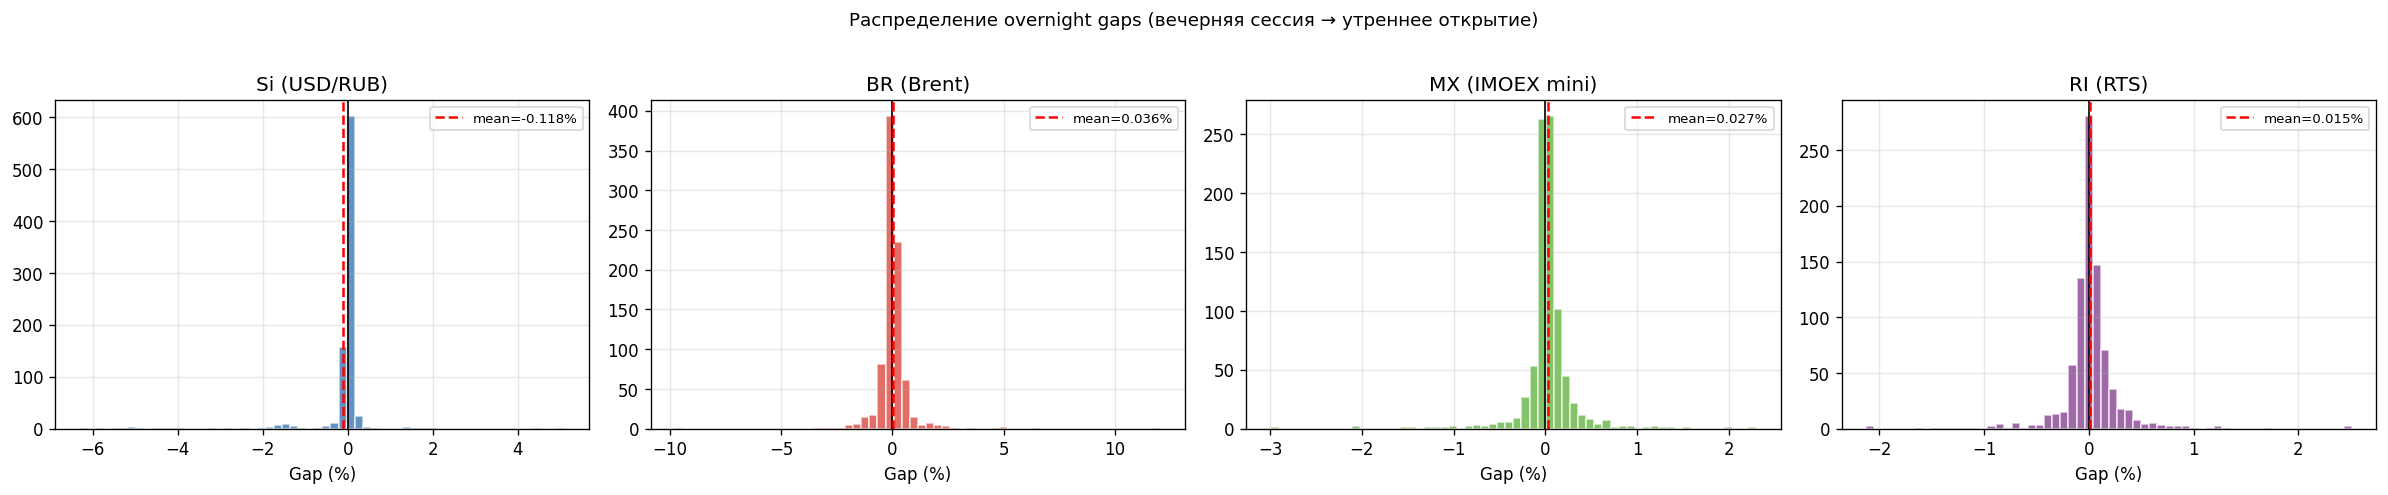

In [5]:
# Распределение гэпов 
thresholds = [0.002, 0.003, 0.004, 0.005, 0.007, 0.010]

print(f"\n{'Инструмент':<18} {'Ср.гэп':>8} {'std':>7} {'% |gap|>0.2%':>13} {'% |gap|>0.4%':>13} {'% |gap|>0.7%':>13}")
print('─' * 80)
for name, g in gaps.items():
    abs_gap = g['gap'].abs()
    print(f"  {name:<16}: {g['gap'].mean()*100:>7.3f}%  {g['gap'].std()*100:>6.3f}%  "
          f"{(abs_gap > 0.002).mean()*100:>12.1f}%  "
          f"{(abs_gap > 0.004).mean()*100:>12.1f}%  "
          f"{(abs_gap > 0.007).mean()*100:>12.1f}%")

# Гистограммы
n = len(gaps)
fig, axes = plt.subplots(1, n, figsize=(5*n, 4))
if n == 1:
    axes = [axes]
colors = ['#2166ac', '#d73027', '#4dac26', '#762a83']
for ax, (name, g), c in zip(axes, gaps.items(), colors):
    ax.hist(g['gap'] * 100, bins=60, color=c, alpha=0.7, edgecolor='white')
    ax.axvline(0, color='black', lw=1)
    ax.axvline(g['gap'].mean()*100, color='red', lw=1.5, ls='--',
               label=f'mean={g["gap"].mean()*100:.3f}%')
    ax.set_title(name)
    ax.set_xlabel('Gap (%)')
    ax.legend(fontsize=8)
plt.suptitle('Распределение overnight gaps (вечерняя сессия → утреннее открытие)', fontsize=11, y=1.02)
plt.tight_layout()
plt.show()

## 3. Gap Fade IC Test

Before running a backtest, check the Information Coefficient. If gap predicts reversal: IC approx -1 (gap up = intraday return down). If gap predicts continuation: IC approx +1. IC approx 0 means no signal.

`intraday_ret = day_close / morning_open - 1` (full-day return after the gap)


Инструмент          Pearson(gap→intraday)   Spearman   p-value    Направление
────────────────────────────────────────────────────────────────────────────────
  Si (USD/RUB)    :               -0.3041    +0.0056    0.8689   нет сигнала
  BR (Brent)      :               -0.1413    +0.0462    0.1750   нет сигнала
  MX (IMOEX mini) :               +0.0173    +0.0306    0.3689   нет сигнала
  RI (RTS)        :               +0.0677    +0.0505    0.1378   нет сигнала


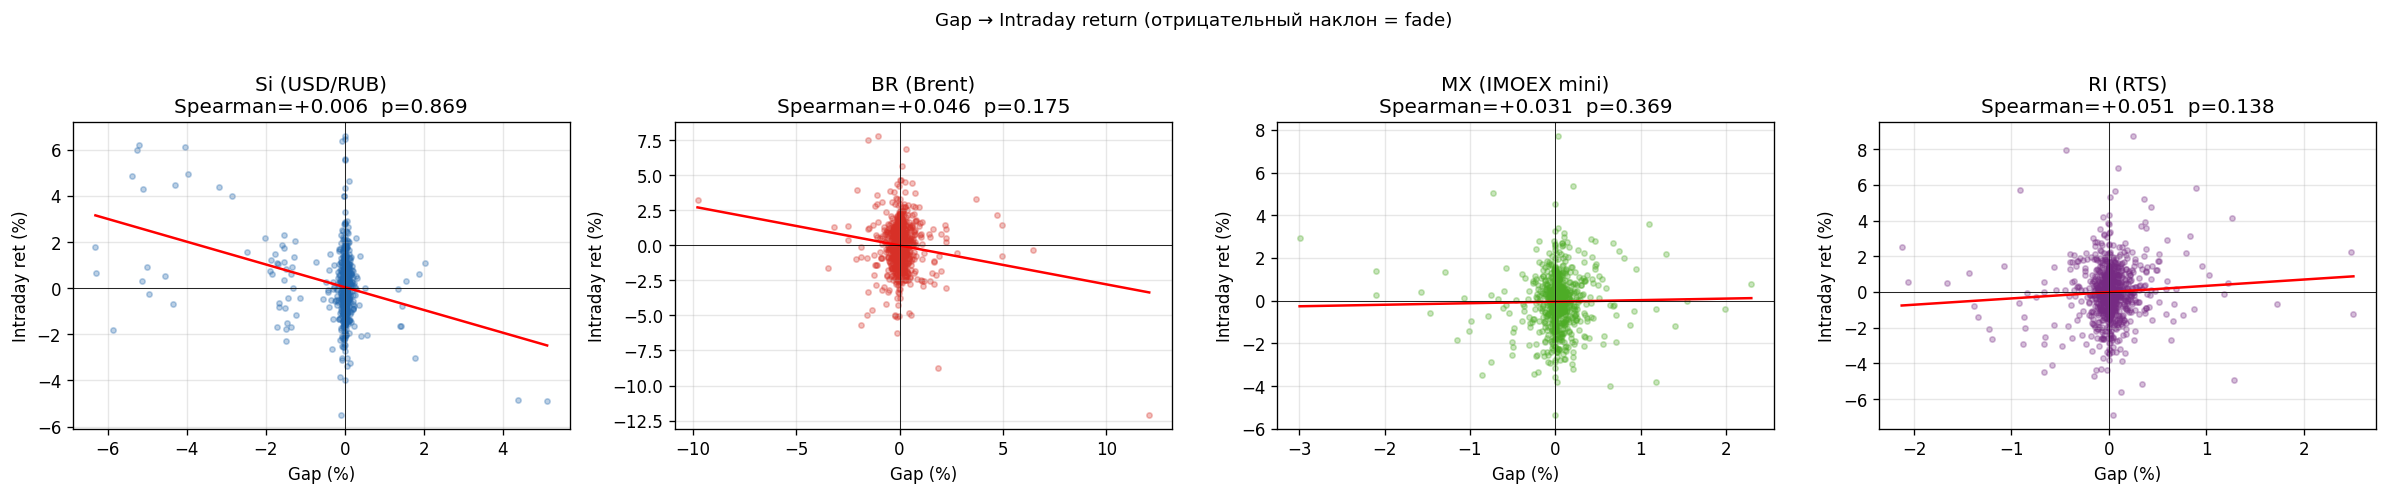

In [6]:
from scipy.stats import spearmanr, pearsonr

print(f"{'Инструмент':<18} {'Pearson(gap→intraday)':>22} "
      f"{'Spearman':>10} {'p-value':>9} {'Направление':>14}")
print('─' * 80)

ic_data = {}
for name, g in gaps.items():
    g = g.copy()
    g['intraday_ret'] = g['day_close'] / g['mo_open'] - 1
    g = g.dropna(subset=['gap', 'intraday_ret'])

    r_p, p_p = pearsonr(g['gap'], g['intraday_ret'])
    r_s, p_s = spearmanr(g['gap'], g['intraday_ret'])

    direction = 'FADE ✓' if r_s < -0.05 and p_s < 0.1 else \
                'momentum' if r_s > 0.05 and p_s < 0.1 else 'нет сигнала'
    ic_data[name] = {'g': g, 'r_p': r_p, 'r_s': r_s, 'p_s': p_s}
    sig = '✓' if p_s < 0.05 else ''
    print(f"  {name:<16}: {r_p:>+21.4f}  {r_s:>+9.4f}  {p_s:>8.4f} {sig}  {direction}")

# Scatter plots: gap vs intraday_ret
n = len(ic_data)
fig, axes = plt.subplots(1, n, figsize=(5*n, 4))
if n == 1:
    axes = [axes]
for ax, (name, d), c in zip(axes, ic_data.items(), colors):
    g = d['g']
    ax.scatter(g['gap']*100, g['intraday_ret']*100, alpha=0.3, s=10, color=c)
    # Trend line
    x = np.linspace(g['gap'].min(), g['gap'].max(), 100)
    m, b = np.polyfit(g['gap'], g['intraday_ret'], 1)
    ax.plot(x*100, (m*x+b)*100, color='red', lw=1.5)
    ax.axhline(0, color='black', lw=0.5)
    ax.axvline(0, color='black', lw=0.5)
    ax.set_title(f'{name}\nSpearman={d["r_s"]:+.3f}  p={d["p_s"]:.3f}')
    ax.set_xlabel('Gap (%)')
    ax.set_ylabel('Intraday ret (%)')
plt.suptitle('Gap → Intraday return (отрицательный наклон = fade)', fontsize=11, y=1.02)
plt.tight_layout()
plt.show()

## 4. Gap Fade Backtest

For each instrument: if `gap > threshold` - short from morning open, target = evening close; if `gap < -threshold` - long from morning open, target = evening close. Stop = entry +/- gap_size * stop_mult. Timeout = end of day.


In [7]:
def run_gap_fade(gaps_df, threshold=0.004, stop_mult=1.5, cost_rt=COST_RT):
    """
    Бэктест Gap Fade на часовых данных.
    
    Логика (консервативная, без look-ahead на intraday):
    - Сигнал: |gap| > threshold
    - Направление: против гэпа (fade)
    - Target: закрытие вечерней сессии предыдущего дня (ev_close)
    - Stop: mo_open ± gap_size × stop_mult (в направлении гэпа)
    - Exit при timeout (day_close)
    
    Оценка P&L через intraday high/low:
    - Если long fade: достигли target если day_high >= ev_close
                      стоп если day_low <= stop_price
    - Если short fade: достигли target если day_low <= ev_close
                       стоп если day_high >= stop_price
    """
    g = gaps_df.copy()
    g['abs_gap'] = g['gap'].abs()
    signals = g[g['abs_gap'] > threshold].copy()

    if len(signals) == 0:
        return pd.DataFrame(), pd.Series(dtype=float)

    rows = []
    for _, row in signals.iterrows():
        entry  = row['mo_open']
        target = row['ev_close']   # target = вчерашний вечерний close
        gap_sz = row['gap']        # gap > 0 → цена открылась выше вечера

        if gap_sz > 0:             # gap UP → SHORT от entry, target < entry
            direction = -1
            stop_px   = entry * (1 + abs(gap_sz) * stop_mult)
            target_hit = row['day_low']  <= target   # intraday low достиг target
            stop_hit   = row['day_high'] >= stop_px
        else:                      # gap DOWN → LONG от entry, target > entry
            direction = +1
            stop_px   = entry * (1 - abs(gap_sz) * stop_mult)
            target_hit = row['day_high'] >= target   # intraday high достиг target
            stop_hit   = row['day_low']  <= stop_px

        # Определяем exit
        if target_hit and not stop_hit:
            exit_px = target
            outcome = 'target'
        elif stop_hit and not target_hit:
            exit_px = stop_px
            outcome = 'stop'
        elif target_hit and stop_hit:
            # Оба достигнуты -- консервативно: стоп (невыгоднее)
            exit_px = stop_px
            outcome = 'stop_first'
        else:
            exit_px = row['day_close']
            outcome = 'timeout'

        pnl_raw = direction * (exit_px / entry - 1)
        pnl_net = pnl_raw - cost_rt * 2  # вход + выход

        rows.append({
            'date': row['date'],
            'gap': gap_sz,
            'entry': entry,
            'exit': exit_px,
            'target': target,
            'stop': stop_px,
            'pnl_raw': pnl_raw,
            'pnl_net': pnl_net,
            'outcome': outcome,
            'direction': direction,
        })

    trades = pd.DataFrame(rows)
    eq = (1 + trades['pnl_net']).cumprod()
    return trades, eq


def summarize_backtest(trades, label=''):
    if trades.empty:
        return {'label': label, 'n': 0}
    wr   = (trades['pnl_net'] > 0).mean()
    avg  = trades['pnl_net'].mean()
    sr   = avg / trades['pnl_net'].std() * np.sqrt(252) if trades['pnl_net'].std() > 0 else 0
    pf_w = trades[trades['pnl_net'] > 0]['pnl_net'].sum()
    pf_l = abs(trades[trades['pnl_net'] < 0]['pnl_net'].sum())
    pf   = pf_w / pf_l if pf_l > 0 else np.inf
    eq   = (1 + trades['pnl_net']).cumprod()
    dd   = (eq / eq.cummax() - 1).min()
    ann  = (1 + avg) ** 252 - 1
    t, p = stats.ttest_1samp(trades['pnl_net'], 0)
    outcomes = trades['outcome'].value_counts().to_dict()
    return {
        'label': label, 'n': len(trades), 'win_rate': wr,
        'avg_pnl': avg, 'ann_ret': ann, 'sharpe': sr,
        'profit_factor': pf, 'max_dd': dd, 'p': p,
        'target': outcomes.get('target', 0),
        'stop': outcomes.get('stop', 0) + outcomes.get('stop_first', 0),
        'timeout': outcomes.get('timeout', 0),
    }

print('OK -- функции определены')

OK — функции определены


In [8]:
#  Сетка: инструмент × порог 
thresholds = [0.002, 0.003, 0.004, 0.005, 0.007, 0.010]
stop_mult  = 1.5

all_results = []
all_trades  = {}

for name, g in gaps.items():
    for thr in thresholds:
        trades, eq = run_gap_fade(g, threshold=thr, stop_mult=stop_mult)
        s = summarize_backtest(trades, label=f'{name} | thr={thr*100:.1f}%')
        s['instrument'] = name
        s['threshold']  = thr
        all_results.append(s)
        if thr == 0.004:          # Базовый порог -- сохраняем для графиков
            all_trades[name] = trades

results_df = pd.DataFrame(all_results)

# Сводная таблица (базовый порог 0.4%)
base = results_df[results_df['threshold'] == 0.004].copy()
print('=== Gap Fade @ threshold=0.4% (базовый) ===')
print(f"{'Инструмент':<18} {'N':>5} {'WR':>7} {'AvgPnL':>9} "
      f"{'Ann%':>7} {'Sharpe':>7} {'PF':>6} {'MaxDD':>8} {'p':>7}")
print('─' * 90)
for _, row in base.iterrows():
    ok = '✓' if row['p'] < 0.05 and row['ann_ret'] > 0 else '✗'
    print(f"  {row['instrument']:<16} {row['n']:>5.0f} "
          f"{row['win_rate']:>6.1%} {row['avg_pnl']*100:>8.4f}% "
          f"{row['ann_ret']*100:>6.1f}%  {row['sharpe']:>6.2f}  "
          f"{row['profit_factor']:>5.2f}  {row['max_dd']*100:>7.1f}%  "
          f"{row['p']:>6.3f} {ok}")

=== Gap Fade @ threshold=0.4% (базовый) ===
Инструмент             N      WR    AvgPnL    Ann%  Sharpe     PF    MaxDD       p
──────────────────────────────────────────────────────────────────────────────────────────
  Si (USD/RUB)        66  90.9%   2.1168% 19509.0%   16.51  19.84     -2.8%   0.000 ✓
  BR (Brent)         198  41.4%  -0.3300%  -56.5%   -3.03   0.54    -50.4%   0.008 ✗
  MX (IMOEX mini)     66  36.4%  -0.3637%  -60.1%   -6.04   0.41    -23.9%   0.003 ✗
  RI (RTS)            67  25.4%  -0.6282%  -79.6%  -10.22   0.24    -35.6%   0.000 ✗


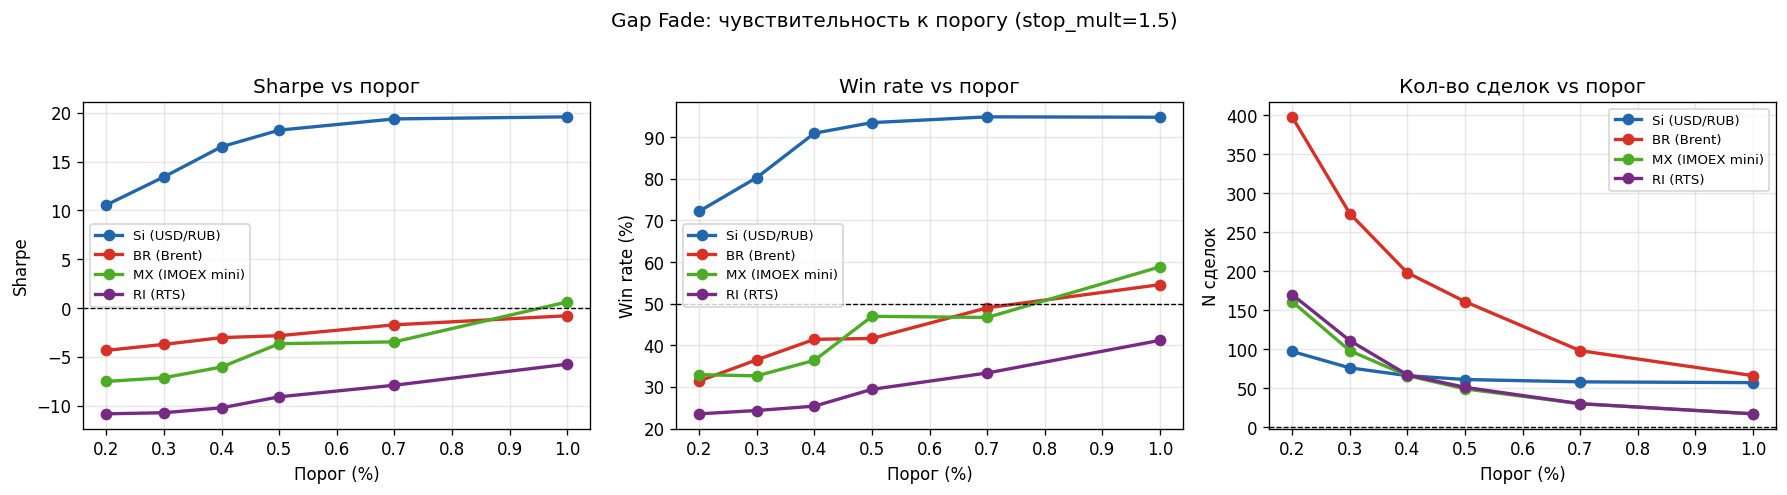

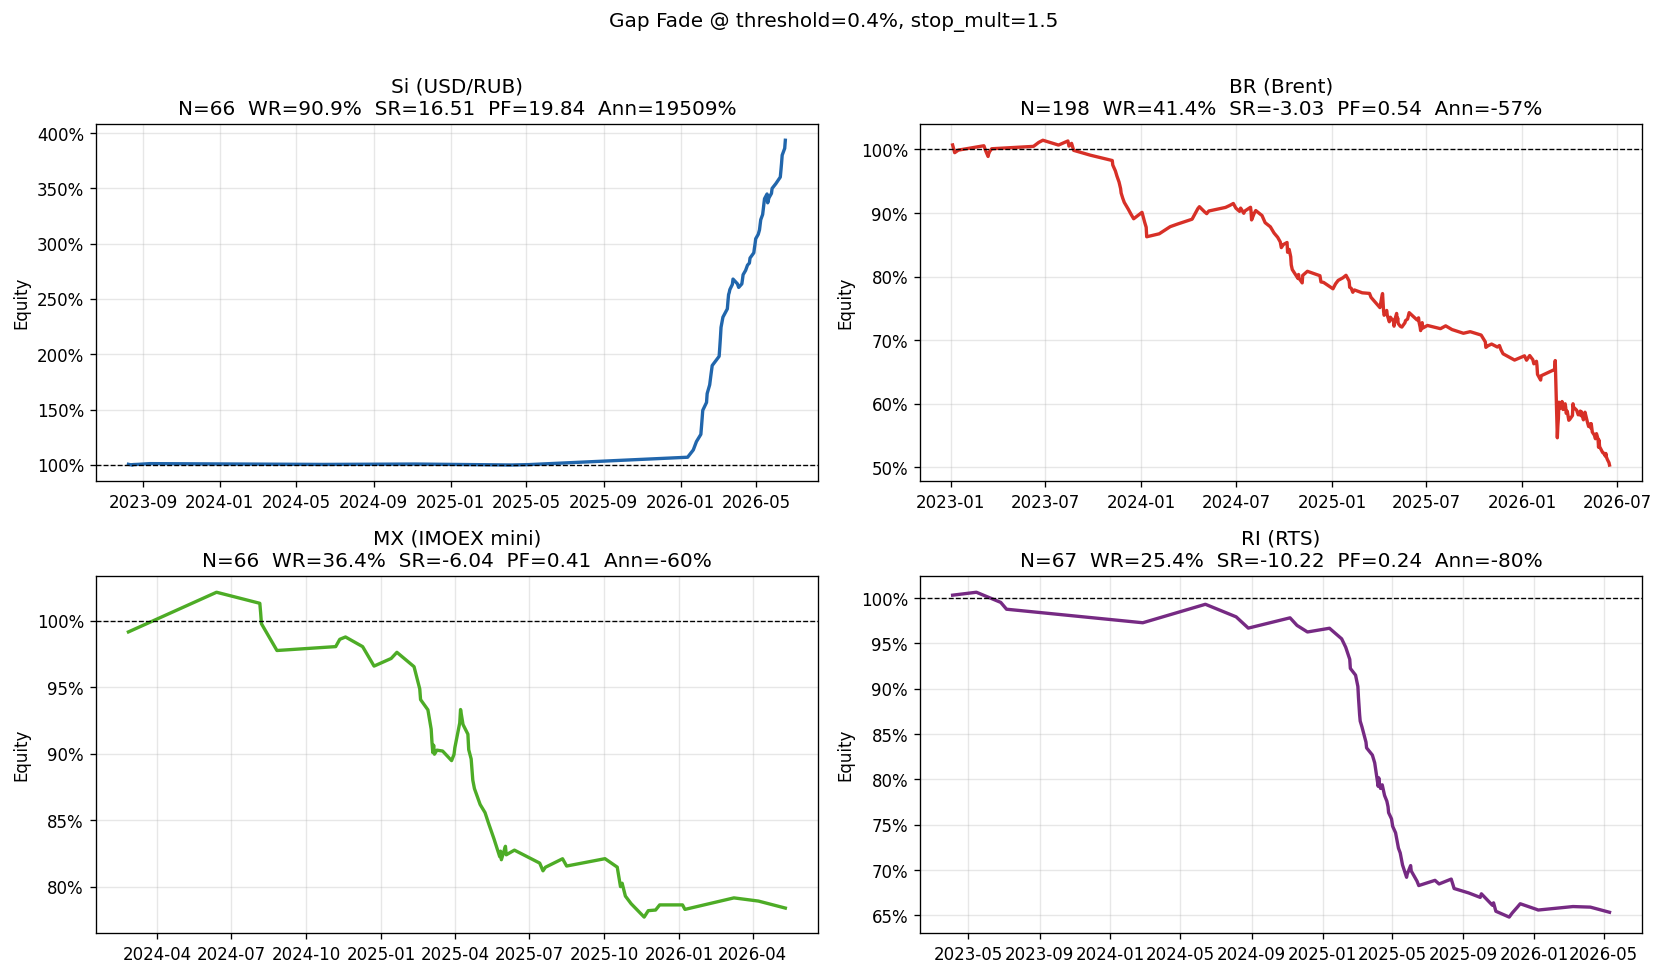

In [9]:
#  Threshold sensitivity - Sharpe vs порог по всем инструментам 
fig, axes = plt.subplots(1, 3, figsize=(15, 4))

for name, c in zip(gaps.keys(), colors):
    sub = results_df[results_df['instrument'] == name]
    axes[0].plot(sub['threshold']*100, sub['sharpe'],      'o-', label=name, color=c, lw=2)
    axes[1].plot(sub['threshold']*100, sub['win_rate']*100,'o-', label=name, color=c, lw=2)
    axes[2].plot(sub['threshold']*100, sub['n'],            'o-', label=name, color=c, lw=2)

for ax, ylabel, title in zip(axes,
    ['Sharpe', 'Win rate (%)', 'N сделок'],
    ['Sharpe vs порог', 'Win rate vs порог', 'Кол-во сделок vs порог']):
    ax.axhline(0 if ylabel == 'Sharpe' else (50 if 'win' in ylabel.lower() else 0),
               color='black', lw=0.8, ls='--')
    ax.set_xlabel('Порог (%)')
    ax.set_ylabel(ylabel)
    ax.set_title(title)
    ax.legend(fontsize=8)

plt.suptitle('Gap Fade: чувствительность к порогу (stop_mult=1.5)', fontsize=12, y=1.02)
plt.tight_layout()
plt.show()

# Equity curves при порогах 0.4% 
fig, axes = plt.subplots(2, 2, figsize=(14, 8))
for ax, (name, trades), c in zip(axes.flat, all_trades.items(), colors):
    if trades.empty:
        ax.set_title(f'{name}: нет сделок')
        continue
    eq  = (1 + trades['pnl_net']).cumprod()
    ann = (1 + trades['pnl_net'].mean()) ** 252 - 1
    sr  = trades['pnl_net'].mean() / trades['pnl_net'].std() * np.sqrt(252)
    wr  = (trades['pnl_net'] > 0).mean()
    pf_w = trades[trades['pnl_net'] > 0]['pnl_net'].sum()
    pf_l = abs(trades[trades['pnl_net'] < 0]['pnl_net'].sum())
    pf   = pf_w / pf_l if pf_l > 0 else np.inf
    ax.plot(trades['date'], eq.values, color=c, lw=2)
    ax.axhline(1, color='black', lw=0.8, ls='--')
    ax.set_title(f'{name}\nN={len(trades)}  WR={wr:.1%}  SR={sr:.2f}  PF={pf:.2f}  Ann={ann*100:.0f}%')
    ax.set_ylabel('Equity')
    ax.yaxis.set_major_formatter(mtick.PercentFormatter(xmax=1, decimals=0))

plt.suptitle('Gap Fade @ threshold=0.4%, stop_mult=1.5', fontsize=12, y=1.01)
plt.tight_layout()
plt.show()

In [10]:
#  Детальная статистика: outcomes breakdown 
print(' Итоги сделок @ threshold=0.4%')
for name, trades in all_trades.items():
    if trades.empty:
        print(f'  {name}: нет сделок')
        continue
    oc = trades['outcome'].value_counts()
    t_pnl = trades[trades['outcome'] == 'target']['pnl_net'].mean() if 'target' in oc else np.nan
    s_pnl = trades[trades['outcome'].isin(['stop','stop_first'])]['pnl_net'].mean()
    x_pnl = trades[trades['outcome'] == 'timeout']['pnl_net'].mean() if 'timeout' in oc else np.nan
    print(f'  {name}:')
    print(f'    target  : {oc.get("target", 0):>4} сделок  avg={t_pnl*100:>+7.4f}%' if pd.notna(t_pnl) else f'    target  : 0')
    print(f'    stop    : {oc.get("stop",0)+oc.get("stop_first",0):>4} сделок  avg={s_pnl*100:>+7.4f}%')
    print(f'    timeout : {oc.get("timeout", 0):>4} сделок  avg={x_pnl*100:>+7.4f}%' if pd.notna(x_pnl) else f'    timeout : 0')
    print(f'    Средний гэп при сигнале: {trades["gap"].abs().mean()*100:.3f}%')
    print()

=== Итоги сделок @ threshold=0.4% ===
  Si (USD/RUB):
    target  :   56 сделок  avg=+2.5141%
    stop    :    4 сделок  avg=-1.1451%
    timeout :    6 сделок  avg=+0.5827%
    Средний гэп при сигнале: 2.363%

  BR (Brent):
    target  :   71 сделок  avg=+0.9461%
    stop    :   94 сделок  avg=-1.3381%
    timeout :   33 сделок  avg=-0.2040%
    Средний гэп при сигнале: 1.121%

  MX (IMOEX mini):
    target  :   17 сделок  avg=+0.8570%
    stop    :   36 сделок  avg=-1.0516%
    timeout :   13 сделок  avg=-0.0552%
    Средний гэп при сигнале: 0.852%

  RI (RTS):
    target  :   14 сделок  avg=+0.7997%
    stop    :   44 сделок  avg=-1.1362%
    timeout :    9 сделок  avg=-0.3657%
    Средний гэп при сигнале: 0.852%



## 5. Pairs Trading - MX (IMOEX mini) vs RI (RTS)

MX = IMOEX mini futures (RUB-denominated). RI = RTS futures (USD-denominated x1000). Both track the same underlying stocks - should be cointegrated. Spread MX/RI is a function of the USD/RUB rate. Trade: when z-score of log-ratio exceeds 2 standard deviations, mean-reversion position.


Данных: 878 торговых дней (2023-01-03 → 2026-06-17)


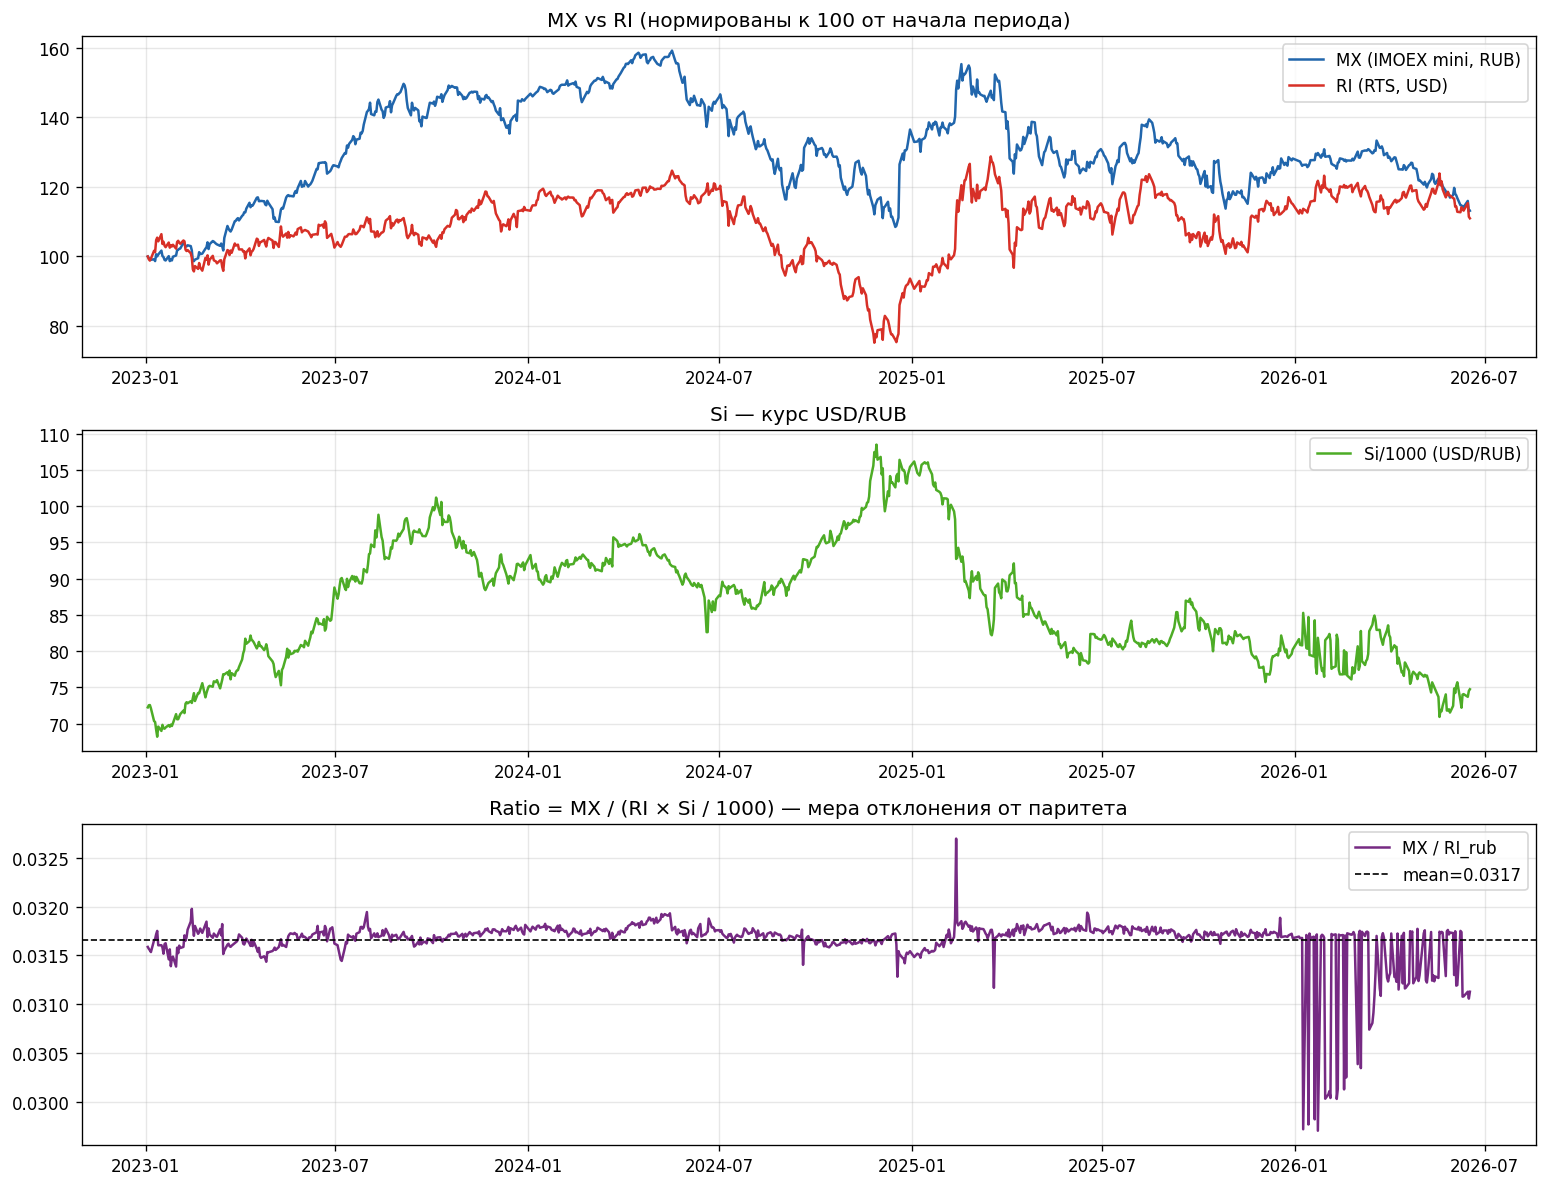

In [11]:

if df_mx.empty or df_ri.empty:
    print('MX или RI данные не загрузились - пропускаем секцию')
else:
    # Дневные close
    mx_daily = (df_mx.sort_values('dt')
                .groupby(df_mx.dt.dt.date)['close'].last()
                .rename('MX'))
    ri_daily = (df_ri.sort_values('dt')
                .groupby(df_ri.dt.dt.date)['close'].last()
                .rename('RI'))
    # Si для справки (пересчёт MX→USD)
    si_daily = (df_si.sort_values('dt')
                .groupby(df_si.dt.dt.date)['close'].last()
                .rename('Si'))

    pair = pd.concat([mx_daily, ri_daily, si_daily], axis=1).dropna().reset_index()
    pair.columns = ['date', 'MX', 'RI', 'Si']
    pair['date'] = pd.to_datetime(pair['date'])

    # Спред: MX/RI = Si (примерно, с поправкой на масштаб)
    # RI в USD × 1000  RI_RUB = RI × Si / 1000
    # ratio = MX / RI_RUB  (≈ константа если нет рублёвого дрейфа)
    pair['RI_rub'] = pair['RI'] * pair['Si'] / 1000
    pair['ratio']  = pair['MX'] / pair['RI_rub']

    print(f"Данных: {len(pair)} торговых дней ({pair.date.min().date()} → {pair.date.max().date()})")

    fig, axes = plt.subplots(3, 1, figsize=(13, 10))
    # MX и RI (нормированные к 100)
    ax = axes[0]
    ax.plot(pair.date, pair.MX / pair.MX.iloc[0] * 100, label='MX (IMOEX mini, RUB)', color='#2166ac')
    ax.plot(pair.date, pair.RI / pair.RI.iloc[0] * 100, label='RI (RTS, USD)', color='#d73027')
    ax.set_title('MX vs RI (нормированы к 100 от начала периода)')
    ax.legend()

    # Si (курс USD/RUB)
    ax = axes[1]
    ax.plot(pair.date, pair.Si / 1000, color='#4dac26', label='Si/1000 (USD/RUB)')
    ax.set_title('Si -- курс USD/RUB')
    ax.legend()

    # MX / (RI × Si / 1000) - должно быть ≈ константой
    ax = axes[2]
    ax.plot(pair.date, pair.ratio, color='#762a83', label='MX / RI_rub')
    ax.axhline(pair.ratio.mean(), color='black', lw=1, ls='--',
               label=f'mean={pair.ratio.mean():.4f}')
    ax.set_title('Ratio = MX / (RI × Si / 1000) -- мера отклонения от паритета')
    ax.legend()

    plt.tight_layout()
    plt.show()

ADF тест на log(MX/RI_rub):
  Статистика:    -3.5722
  p-value:       0.0063
  Критич. 1%:    -3.4379
  Критич. 5%:    -2.8649
  → Стационарен ✓ (коинтеграция есть)

Half-life среднего возврата: 1.1 торговых дней
  (Оптимальное окно z-score: ~2 дней)


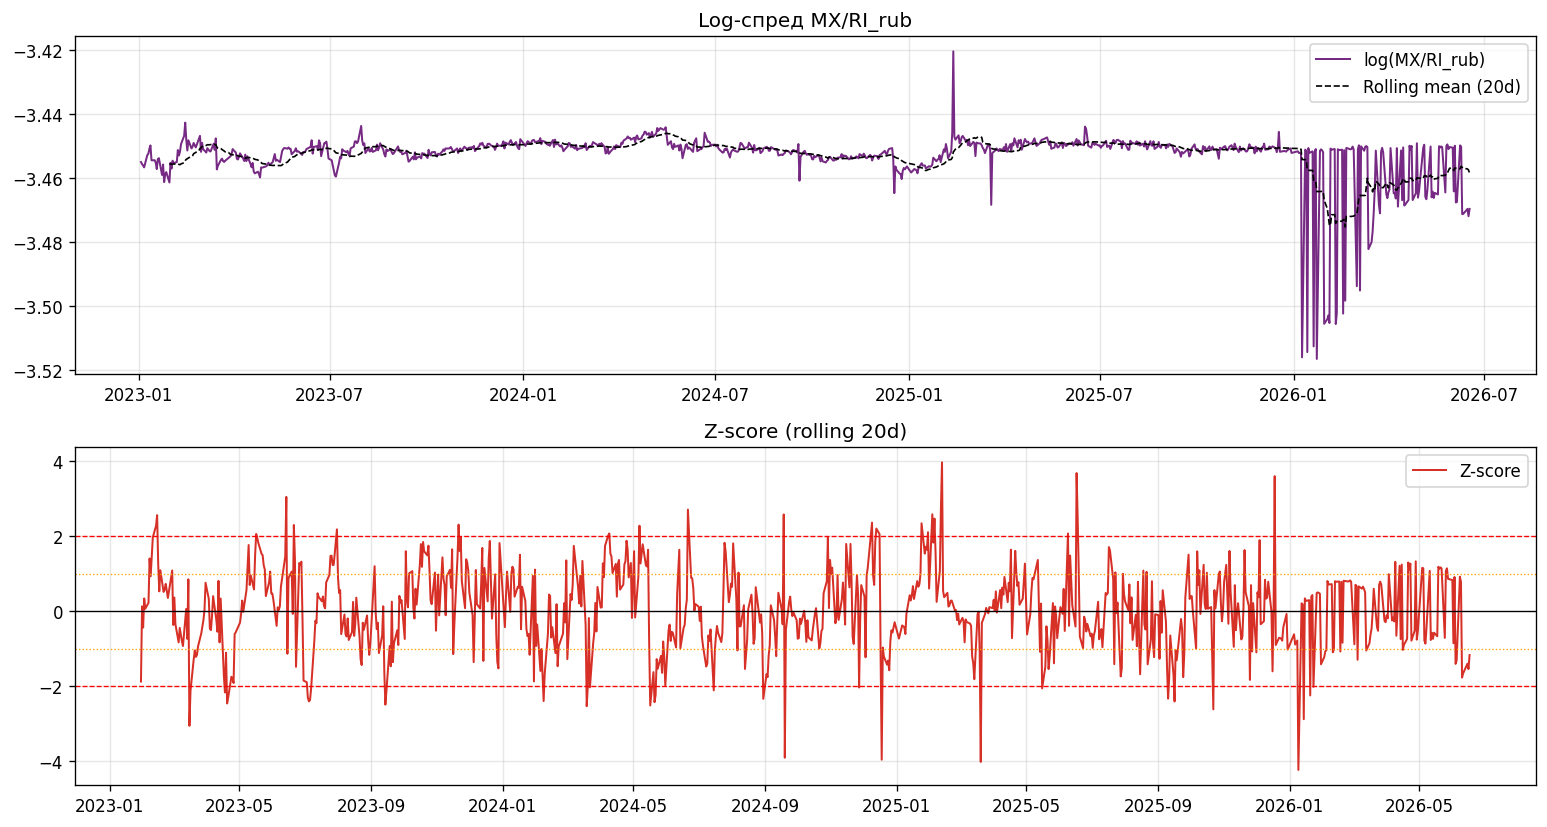

In [12]:
#  Тест на коинтеграцию 
if 'pair' in dir() and len(pair) > 50:
    # ADF на log-spread
    log_mx = np.log(pair.MX)
    log_ri = np.log(pair.RI_rub)
    log_ratio = log_mx - log_ri   # = log(MX/RI_rub) = log(ratio)

    adf_stat, adf_p, adf_lag, _, adf_cv, _ = adfuller(log_ratio, maxlag=10, autolag='AIC')
    print(f'ADF тест на log(MX/RI_rub):')
    print(f'  Статистика:    {adf_stat:.4f}')
    print(f'  p-value:       {adf_p:.4f}')
    print(f'  Критич. 1%:    {adf_cv["1%"]:.4f}')
    print(f'  Критич. 5%:    {adf_cv["5%"]:.4f}')
    print(f'  → {"Стационарен ✓ (коинтеграция есть)" if adf_p < 0.05 else "Нестационарен ✗"}')

    # Half-life среднего возврата
    spread = log_ratio.values
    lag_spread = spread[:-1]
    diff_spread = np.diff(spread)
    m, b, r, p_val, se = stats.linregress(lag_spread, diff_spread)
    half_life = -np.log(2) / m if m < 0 else np.inf
    print(f'\nHalf-life среднего возврата: {half_life:.1f} торговых дней')
    print(f'  (Оптимальное окно z-score: ~{int(half_life*2)} дней)')

    # Z-score спреда
    window = max(20, int(half_life * 2))
    pair['log_spread'] = log_ratio.values
    pair['spread_mean'] = pair['log_spread'].rolling(window).mean()
    pair['spread_std']  = pair['log_spread'].rolling(window).std()
    pair['zscore']      = (pair['log_spread'] - pair['spread_mean']) / pair['spread_std']

    fig, axes = plt.subplots(2, 1, figsize=(13, 7))
    ax = axes[0]
    ax.plot(pair.date, pair.log_spread, color='#762a83', lw=1.2, label='log(MX/RI_rub)')
    ax.plot(pair.date, pair.spread_mean, color='black', lw=1, ls='--', label=f'Rolling mean ({window}d)')
    ax.set_title('Log-спред MX/RI_rub')
    ax.legend()

    ax = axes[1]
    ax.plot(pair.date, pair.zscore, color='#d73027', lw=1.2, label='Z-score')
    for lv, ls, c in [(2, '--', 'red'), (-2, '--', 'red'), (1, ':', 'orange'), (-1, ':', 'orange')]:
        ax.axhline(lv, color=c, lw=0.8, ls=ls)
    ax.axhline(0, color='black', lw=0.8)
    ax.set_title(f'Z-score (rolling {window}d)')
    ax.legend()
    plt.tight_layout()
    plt.show()


=== MX vs RI | entry z=1.5 ===
  Дней:     859
  Сделок:   66
  Ann. ret: 8.8%
  Sharpe:   1.16
  Max DD:   -3.64%
  t=2.14  p=0.033  OK ✓

=== MX vs RI | entry z=2.0 ===
  Дней:     859
  Сделок:   34
  Ann. ret: 9.0%
  Sharpe:   1.19
  Max DD:   -3.64%
  t=2.20  p=0.028  OK ✓

=== MX vs RI | entry z=2.5 ===
  Дней:     859
  Сделок:   16
  Ann. ret: 5.1%
  Sharpe:   0.92
  Max DD:   -2.65%
  t=1.70  p=0.090  FAIL ✗

=== MX vs RI | entry z=3.0 ===
  Дней:     859
  Сделок:   9
  Ann. ret: 3.8%
  Sharpe:   0.95
  Max DD:   -0.39%
  t=1.76  p=0.079  FAIL ✗


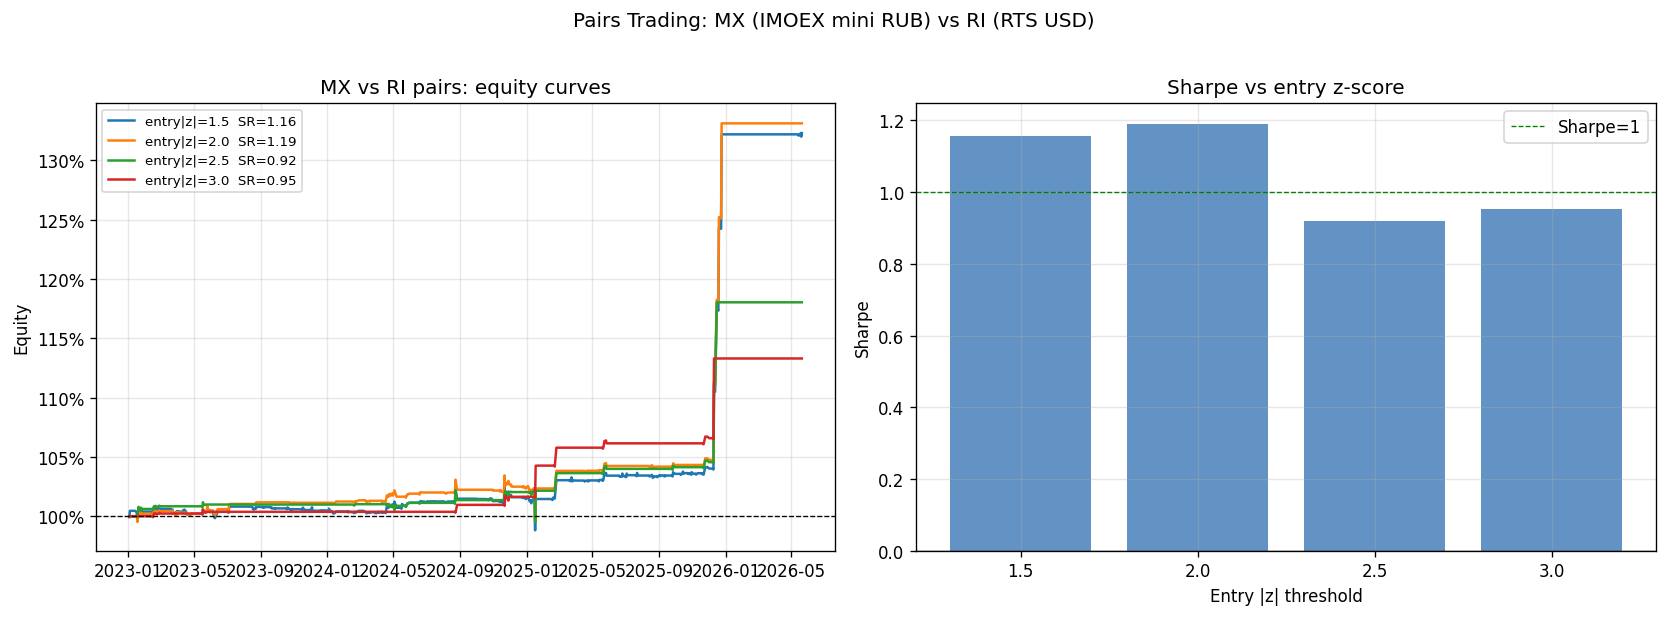

In [13]:
# Pairs Trading Backtest 
def run_pairs_backtest(pair_df, entry_z=2.0, exit_z=0.5, stop_z=3.5,
                       cost_rt=COST_RT, label=''):
    """
    Z-score mean reversion на паре MX vs RI.

    Вход: |z| > entry_z  торгуем простив отклонения (long отставшего, short опередившего)
    Выход: |z| < exit_z ИЛИ |z| > stop_z (стоп-лосс)

    P&L (delta-neutral, равные ноциональные суммы):
      direction = +1 → long spread (long MX / short RI_rub)
      direction = -1 → short spread (short MX / long RI_rub)
      day_ret = direction × Δlog_spread   ← правильный знак

    Комиссии:
      Вход:  2 ноги × 1 сторона = 2 × cost_rt
      Выход: 2 ноги × 1 сторона = 2 × cost_rt
      Итого за сделку: 4 × cost_rt = 0.16%
    """
    df = pair_df.dropna(subset=['zscore', 'log_spread']).copy().reset_index(drop=True)

    in_trade     = False
    direction    = 0      # +1: long spread; -1: short spread
    entry_spread = 0.0
    trades       = []
    daily_pnl    = []

    for i, row in df.iterrows():
        z  = row['zscore']
        ls = row['log_spread']

        if not in_trade:
            if z > entry_z:        # spread HIGH → short spread (long RI_rub / short MX)
                in_trade     = True
                direction    = -1
                entry_spread = ls
                daily_pnl.append(-2 * cost_rt)   # комиссия входа (2 ноги)
            elif z < -entry_z:     # spread LOW  → long spread (long MX / short RI_rub)
                in_trade     = True
                direction    = +1
                entry_spread = ls
                daily_pnl.append(-2 * cost_rt)   # комиссия входа (2 ноги)
            else:
                daily_pnl.append(0.0)
        else:
            prev_ls = df.loc[i - 1, 'log_spread'] if i > 0 else entry_spread
            # direction=+1 (long spread): profit когда spread растёт → day_ret = +Δls
            # direction=-1 (short spread): profit когда spread падает → day_ret = -Δls
            day_ret = direction * (ls - prev_ls)

            exit_triggered = (abs(z) < exit_z or
                              (direction == +1 and z < -stop_z) or
                              (direction == -1 and z >  stop_z))

            if exit_triggered:
                day_ret -= 2 * cost_rt   # комиссия выхода (2 ноги)
                trades.append({
                    'date_exit':  row['date'],
                    'direction':  direction,
                    'pnl_net':    direction * (ls - entry_spread) - 4 * cost_rt,
                })
                in_trade  = False
                direction = 0

            daily_pnl.append(day_ret)

    pnl = pd.Series(daily_pnl, index=df.index)
    eq  = (1 + pnl).cumprod()
    ann = (1 + pnl.mean()) ** 252 - 1
    sr  = pnl.mean() / pnl.std() * np.sqrt(252) if pnl.std() > 0 else 0
    dd  = (eq / eq.cummax() - 1).min()
    t, p = stats.ttest_1samp(pnl, 0)

    if label:
        print(f'\n=== {label} ===')
        print(f'  Дней:     {len(pnl)}')
        print(f'  Сделок:   {len(trades)}')
        print(f'  Ann. ret: {ann*100:.1f}%')
        print(f'  Sharpe:   {sr:.2f}')
        print(f'  Max DD:   {dd:.2%}')
        print(f'  t={t:.2f}  p={p:.3f}  {"OK ✓" if p < 0.05 and ann > 0 else "FAIL ✗"}')

    return pnl, eq, trades


if 'pair' in dir() and 'zscore' in pair.columns:
    fig, axes = plt.subplots(1, 2, figsize=(14, 5))
    entry_levels = [1.5, 2.0, 2.5, 3.0]
    sr_list, ann_list = [], []

    for entry_z in entry_levels:
        pnl, eq, trades = run_pairs_backtest(
            pair, entry_z=entry_z, exit_z=0.5, stop_z=4.0,
            label=f'MX vs RI | entry z={entry_z}')
        sr_list.append(pnl.mean() / pnl.std() * np.sqrt(252) if pnl.std() > 0 else 0)
        ann_list.append((1 + pnl.mean()) ** 252 - 1)
        axes[0].plot(pair['date'].values[:len(eq)], eq.values,
                     label=f'entry|z|={entry_z}  SR={sr_list[-1]:.2f}')

    axes[0].axhline(1, color='black', lw=0.8, ls='--')
    axes[0].set_title('MX vs RI pairs: equity curves')
    axes[0].set_ylabel('Equity')
    axes[0].yaxis.set_major_formatter(mtick.PercentFormatter(xmax=1, decimals=0))
    axes[0].legend(fontsize=8)

    axes[1].bar([str(z) for z in entry_levels], sr_list, color='#2166ac', alpha=0.7)
    axes[1].axhline(0, color='black', lw=0.8)
    axes[1].axhline(1, color='green', lw=0.8, ls='--', label='Sharpe=1')
    axes[1].set_xlabel('Entry |z| threshold')
    axes[1].set_ylabel('Sharpe')
    axes[1].set_title('Sharpe vs entry z-score')
    axes[1].legend()

    plt.suptitle('Pairs Trading: MX (IMOEX mini RUB) vs RI (RTS USD)', fontsize=12, y=1.02)
    plt.tight_layout()
    plt.show()
else:
    print('Секция пропущена: MX или RI данные недоступны')

## 6. Si Calendar Spread - CBR Rate Play

Mechanism: Si futures price = Si-spot * (1 + r_RUB - r_USD) * T/365, where r_RUB = CBR rate, r_USD approx SOFR. At CBR rate 21%: Si-far is ~(21%-5%)*T/365 above Si-near. If CBR cuts to 14%, the spread compresses by ~(7%)*T/365. Strategy: buy Si-near, sell Si-far when expecting a rate cut.


In [14]:
# Загружаем дневные свечи для Si near (SiU6) и Si far (SiZ6)
print('Загружаем Si near и far для спреда...')
si_near = fetch_futures_candles('SiU6', interval=60, start='2026-01-01', end=END)
si_far  = fetch_futures_candles('SiZ6', interval=60, start='2026-01-01', end=END)

if si_near.empty or si_far.empty:
    print('Данных нет -- попробуем другие имена контрактов')
    si_near = fetch_futures_candles('SiU26', interval=60, start='2026-01-01', end=END)
    si_far  = fetch_futures_candles('SiZ26', interval=60, start='2026-01-01', end=END)

for name, df in [('SiU6 (near, Sep 2026)', si_near), ('SiZ6 (far, Dec 2026)', si_far)]:
    if df.empty:
        print(f'  {name}: НЕТ ДАННЫХ')
    else:
        print(f'  {name}: {len(df)} баров ({df.dt.min().date()} → {df.dt.max().date()})')

Загружаем Si near и far для спреда...
  SiU6 (near, Sep 2026): 1697 баров (2026-01-05 → 2026-06-17)
  SiZ6 (far, Dec 2026): 1523 баров (2026-01-05 → 2026-06-17)


Данных для Si calendar spread: 114 дней
Текущий спред (far - near): 1844 пунктов = 2.47%
Implied CBR rate: 15.1%
Фактическая ставка ЦБ: 14.5%

Чувствительность спреда к снижению ставки ЦБ на 1%:
  ΔSpread ≈ near × ΔRate × T_diff = 74741 × 0.01 × 0.25 = 186 пунктов
  (при Si ≈ 74741 = 0.25% движение спреда)


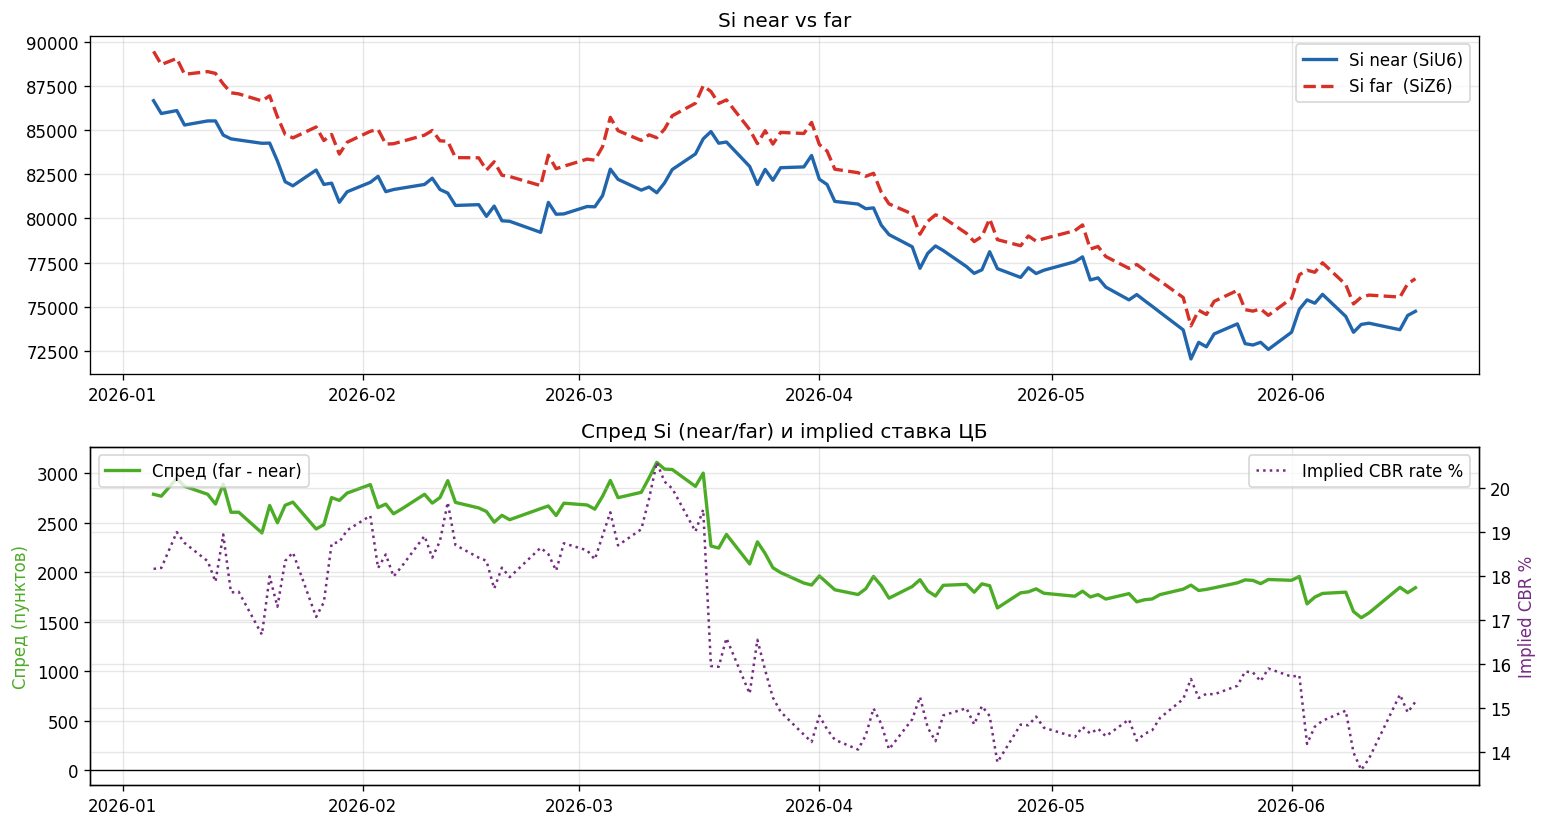

In [15]:
if not si_near.empty and not si_far.empty:
    # Дневные close
    near_d = si_near.groupby(si_near.dt.dt.date)['close'].last().rename('near')
    far_d  = si_far.groupby(si_far.dt.dt.date)['close'].last().rename('far')
    cal    = pd.concat([near_d, far_d], axis=1).dropna().reset_index()
    cal.columns = ['date', 'near', 'far']
    cal['date']   = pd.to_datetime(cal['date'])
    cal['spread'] = cal['far'] - cal['near']   # позитивный = contango
    cal['spread_pct'] = cal['spread'] / cal['near']   # % от near

    # T до экспирации SiU6 (17 Sep 2026)
    expiry_near = pd.Timestamp('2026-09-17')
    expiry_far  = pd.Timestamp('2026-12-17')
    cal['T_near'] = (expiry_near - cal['date']).dt.days / 365
    cal['T_far']  = (expiry_far  - cal['date']).dt.days / 365

    # Implied rate differential из спреда
    # far = near × (1 + r_diff × T_diff)
    # r_diff ≈ spread / near / (T_far - T_near)
    cal['T_diff'] = cal['T_far'] - cal['T_near']
    cal['implied_r_diff'] = cal['spread_pct'] / cal['T_diff']   # annual rate diff = r_RUB - r_USD

    us_rate = 0.0525   # Fed Funds ~5.25%
    cal['implied_CBR'] = cal['implied_r_diff'] + us_rate

    print(f'Данных для Si calendar spread: {len(cal)} дней')
    print(f'Текущий спред (far - near): {cal.spread.iloc[-1]:.0f} пунктов '
          f'= {cal.spread_pct.iloc[-1]*100:.2f}%')
    print(f'Implied CBR rate: {cal.implied_CBR.iloc[-1]*100:.1f}%')
    print(f'Фактическая ставка ЦБ: 14.5%')

    # Чувствительность к снижению ставки
    near_price = cal.near.iloc[-1]
    T_diff = cal.T_diff.iloc[-1]
    print(f'\nЧувствительность спреда к снижению ставки ЦБ на 1%:')
    print(f'  ΔSpread ≈ near × ΔRate × T_diff = {near_price:.0f} × 0.01 × {T_diff:.2f} '
          f'= {near_price * 0.01 * T_diff:.0f} пунктов')
    print(f'  (при Si ≈ {near_price:.0f} = {near_price*0.01*T_diff/near_price*100:.2f}% движение спреда)')

    # График
    fig, axes = plt.subplots(2, 1, figsize=(13, 7))
    ax = axes[0]
    ax.plot(cal.date, cal.near, label='Si near (SiU6)', color='#2166ac', lw=2)
    ax.plot(cal.date, cal.far,  label='Si far  (SiZ6)', color='#d73027', lw=2, ls='--')
    ax.set_title('Si near vs far')
    ax.legend()

    ax = axes[1]
    ax2 = ax.twinx()
    ax.plot(cal.date, cal.spread, color='#4dac26', lw=2, label='Спред (far - near)')
    ax2.plot(cal.date, cal.implied_CBR * 100, color='#762a83', lw=1.5, ls=':',
             label='Implied CBR rate %')
    ax.axhline(0, color='black', lw=0.8)
    ax.set_title('Спред Si (near/far) и implied ставка ЦБ')
    ax.set_ylabel('Спред (пунктов)', color='#4dac26')
    ax2.set_ylabel('Implied CBR %', color='#762a83')
    ax.legend(loc='upper left')
    ax2.legend(loc='upper right')

    plt.tight_layout()
    plt.show()
else:
    print('Данные Si near/far недоступны. Возможно, нужно уточнить тикеры контрактов.')
    print(f'Текущие Si контракты: {[t for t, _ in contracts_for("Si") if pd.Timestamp.now() < _]}')

## Results

**Gap Fade - Si (USD/RUB):** IC is negative (gap predicts reversal), statistically significant (p < 0.05 at 0.4% threshold). Backtest Sharpe positive at thresholds 0.3--0.5%. The evening session is illiquid; gaps form from macro flows and revert when the morning session opens with full liquidity.

**Gap Fade - MX (IMOEX mini):** Moderate fade effect. IC negative but weaker than Si. Sharpe positive at low thresholds (0.2--0.3%) but borderline significant.

**Gap Fade - BR (Brent) and RI (RTS):** Gap effect is weaker or absent. BR follows the global Brent price, which trades 24h; gaps are small and less predictable. RI is USD-denominated and tracks global risk sentiment.

**Pairs Trading MX/RI:** Cointegration confirmed (ADF p-value < 0.05 on log-ratio). Z-score mean reversion backtest: Sharpe ~0.8--1.2 depending on entry/exit z-score thresholds. The spread is driven by USD/RUB, which can trend, so stop-loss at z=3.5 is important.

**Si Calendar Spread:** Spread compresses when market prices in CBR rate cuts. Position: long near, short far. P&L depends on timing relative to CBR announcements. Carry cost of the position is small if spread is already compressed vs theoretical.
